CFID

In [20]:
%%time
import os
if not os.path.exists('jarvis_leaderboard'):
  !git clone https://github.com/atomgptlab/jarvis_leaderboard.git
os.chdir('jarvis_leaderboard')
!pip install -q -e .

ERROR: file:///content/jarvis_leaderboard/jarvis_leaderboard does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.
CPU times: user 1.14 s, sys: 151 ms, total: 1.3 s
Wall time: 2.2 s


In [21]:
!jarvis_populate_data.py --benchmark_file AI-SinglePropertyPrediction-formula_energy-ssub-test-mae --output_path=Out --json_key formula --id_tag id

/usr/local/bin/jarvis_populate_data.py:4: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  __import__('pkg_resources').require('jarvis-leaderboard==2025.9.3')
benchmark_file AI-SinglePropertyPrediction-formula_energy-ssub-test-mae
dataset ssub
output_path Out
property formula_energy
method AI
task SinglePropertyPrediction
id_tag id
out_format poscar
json_key formula
dataset file to be used /content/jarvis_leaderboard/jarvis_leaderboard/benchmarks/AI/SinglePropertyPrediction/ssub_formula_energy.json.zip
Currently for following  datasets only.
https://atomgptlab.github.io/jarvis/databases/
Obtaining SSUB dataset 1726...
Reference:https://github.com/wolverton-research-group/qmpy
Loading the zipfile...
Loading completed.
number of training samples 1381
number of validation samples 0
number of test samples 345


In [22]:
from jarvis.db.jsonutils import loadjson
dataset_info = loadjson('Out/dataset_info.json')

In [23]:
import pandas as pd
df = pd.read_csv('Out/id_prop.csv',header=None,names=['formula','form_energy'])
df['id'] = df.index + 1

In [24]:
df

,formula,form_energy,id
0,CaO4W,-2.841796e+00,1
1,Ho,1.766051e-09,2
2,PbTe,-3.555857e-01,3
3,MoS2,-9.540103e-01,4
4,BeH2,-6.564038e-02,5
...,...,...,...
1721,NZr,-1.892842e+00,1722
1722,CrLiO2,-2.404511e+00,1723
1723,BiNa3,-4.946426e-01,1724
1724,Br4Ge,-7.213532e-01,1725


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:    4.5s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    4.5s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.0s finished


Test MAE: 0.21868670626959397
Model saved to rf_form_energy_model_cfid.pkl


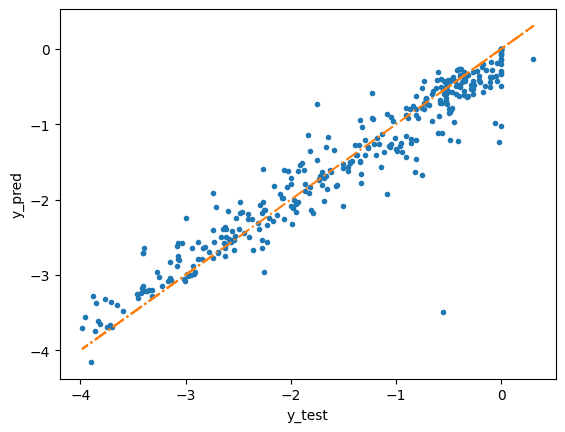

SrTiO3MoSWN: predicted formation energy = -1.6323 eV/atom
Already exists: /content/jarvis_leaderboard/jarvis_leaderboard/contributions/cfid_chem_jhurtad5_tutorial
Saved /content/jarvis_leaderboard/jarvis_leaderboard/contributions/cfid_chem_jhurtad5_tutorial/AI-SinglePropertyPrediction-formula_energy-ssub-test-mae.csv with 345 rows
Zipped to /content/jarvis_leaderboard/jarvis_leaderboard/contributions/cfid_chem_jhurtad5_tutorial/AI-SinglePropertyPrediction-formula_energy-ssub-test-mae.csv.zip
Saved /content/jarvis_leaderboard/jarvis_leaderboard/contributions/cfid_chem_jhurtad5_tutorial/metadata.json
Saved /content/jarvis_leaderboard/jarvis_leaderboard/contributions/cfid_chem_jhurtad5_tutorial/run.sh


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.0s finished


In [28]:
from jarvis.ai.descriptors.cfid import get_chem_only_descriptors
desc, names = get_chem_only_descriptors('MoS2')

desc, desc.shape

df['cfid_desc'] = df['formula'].apply(lambda f: get_chem_only_descriptors(f)[0])

df

train_df=df[:dataset_info['n_train']]
test_df=df[dataset_info['n_train']:]
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
    verbose=1,
)
import numpy as np
import pickle

# Prepare features and target
X_train = np.array(train_df['cfid_desc'].tolist())
y_train = train_df['form_energy'].values

X_test = np.array(test_df['cfid_desc'].tolist())
y_test = test_df['form_energy'].values

# Train
rf.fit(X_train, y_train)

# Evaluate
from sklearn.metrics import mean_absolute_error
y_pred = rf.predict(X_test)
print("Test MAE:", mean_absolute_error(y_test, y_pred))

# Pickle the model
with open("rf_form_energy_model_cfid.pkl", "wb") as f:
    pickle.dump(rf, f)
print("Model saved to rf_form_energy_model_cfid.pkl")


%matplotlib inline
import matplotlib.pyplot as plt
plt.plot(y_test, y_pred,'.')
plt.plot(y_test, y_test,'-.')
plt.xlabel('y_test')
plt.ylabel('y_pred')
plt.show()

import pickle
import numpy as np

# Load the model
with open("rf_form_energy_model_cfid.pkl", "rb") as f:
    rf = pickle.load(f)

# Predict on any compound
formula = "SrTiO3MoSWN"  # change to whatever you want
desc = get_chem_only_descriptors(formula)[0]
pred = rf.predict([desc])[0]
print(f"{formula}: predicted formation energy = {pred:.4f} eV/atom")

your_jhu_id = 'cfid_chem_jhurtad5'
folder_path = f"/content/jarvis_leaderboard/jarvis_leaderboard/contributions/{your_jhu_id}_tutorial"
if not os.path.exists(folder_path):
    os.makedirs(folder_path, exist_ok=True)
    print(f"Created: {folder_path}")
else:
    print(f"Already exists: {folder_path}")

y_pred = rf.predict(X_test)

results = pd.DataFrame({
    'id': test_df['id'].values,
    'formula': test_df['formula'].values,
    'prediction': y_pred,
    'target': test_df['form_energy'].values
})
filename = os.path.join(folder_path, dataset_info['benchmark_file'] + '.csv')
results.to_csv(filename, index=False)

import zipfile
zipname = filename + '.zip'
with zipfile.ZipFile(zipname, 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write(filename, os.path.basename(filename))

print(f"Saved {filename} with {len(results)} rows")
print(f"Zipped to {zipname}")


import json

metadata = {
    "model_name": "CFID‑descriptor‑based model",
    "project_url": "https://github.com/atomgptlab/jarvis",
    "date_submitted": "04-09-2026",
    "author_email": "jhurtad5@.edu",
    "database_version": "12-12-2022",
    "team_name": "JHU",
    "time_taken_seconds": {
        "AI-SinglePropertyPrediction-formula_energy-ssub-test-mae.csv.zip": "",
    },
    "language": "python",
    "os": "linux",
    "software_used": "jarvis-tools,numpy,scipy,torch,alignn",
    "hardware_used": "Colab",
    "git_url": []
}
with open(f'{folder_path}/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)
print(f"Saved {folder_path}/metadata.json")

run_sh = """#!/bin/bash
pip install -q jarvis-tools scikit-learn tqdm

python -c "
import os
import numpy as np
import pickle
import pandas as pd
from tqdm import tqdm
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from jarvis.db.jsonutils import loadjson
from jarvis.ai.descriptors.elemental import get_element_fraction_desc

# Clone and install
# Setup
os.makedirs('Software', exist_ok=True)
os.chdir('Software')
if not os.path.exists('jarvis_leaderboard'):
    os.system('git clone https://github.com/atomgptlab/jarvis_leaderboard.git')
os.system('pip install -q ./jarvis_leaderboard')
os.chdir('..')

# Populate data
os.system('jarvis_populate_data.py --benchmark_file AI-SinglePropertyPrediction-formula_energy-ssub-test-mae --output_path=Out --json_key formula --id_tag id')

# Load data
dataset_info = loadjson('Out/dataset_info.json')
df = pd.read_csv('Out/id_prop.csv', header=None, names=['formula', 'form_energy'])
df['id'] = df.index + 1

tqdm.pandas()
df['desc'] = df['formula'].progress_apply(lambda f: get_element_fraction_desc(f))

train_df = df[:dataset_info['n_train']]
test_df = df[dataset_info['n_train']:]

# Train
X_train = np.array(train_df['desc'].tolist())
y_train = train_df['form_energy'].values
X_test = np.array(test_df['desc'].tolist())
y_test = test_df['form_energy'].values

rf = RandomForestRegressor(
    n_estimators=200, max_depth=None, min_samples_split=2,
    min_samples_leaf=1, max_features='sqrt', n_jobs=-1,
    random_state=42, verbose=1,
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print('Test MAE:', mean_absolute_error(y_test, y_pred))

with open('rf_form_energy_model.pkl', 'wb') as f:
    pickle.dump(rf, f)
print('Model saved to rf_form_energy_model.pkl')

# Save results
results = pd.DataFrame({
    'id': test_df['id'].values,
    'formula': test_df['formula'].values,
    'prediction': y_pred,
    'target': test_df['form_energy'].values
})
filename = dataset_info['benchmark_file'] + '.csv'
results.to_csv(filename, index=False)

import zipfile
with zipfile.ZipFile(filename + '.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write(filename, filename)
print(f'Saved {filename} and {filename}.zip')
"
"""

with open(f'{folder_path}/run.sh', 'w') as f:
    f.write(run_sh)
print(f"Saved {folder_path}/run.sh")